# **STAGE 3 - VISUALISATION**

## Objectives

* In this final section, I will use data visualisation tools to assess the following hypotheses:


|**Hypothesis**| **Description**|
|--------------|----------------|
|**H1**| Donors aged 50 - 65 give more per transaction than other age brackets |


## Inputs

* The input needed for this notebook is the cleaned dataset created in **Stage 2 - ETL**. 
* The relative path for this .csv file is: `datasets/cleaned-data/animal_charity_donation_records_cleaned.csv`

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/wildlife-charity-giving-analytics/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/wildlife-charity-giving-analytics'

---

# Import Packages and Libraries

In order to read `animal_charity_donation_records_cleaned.csv` and created data visualisations to analyse my 5 hypotheses, I need to import the following libraries and packages:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

---

# Data Type Changes Prior to Visualisation

* In **Stage 2 - ETL**, we looked at Transforming some of the columns through changing their data type: specifically, `age_group` and `donation_date`. 
* When saving the cleaned DataFrame to a new .csv file to be used in this notebook, the data type changes were lost and will need to be repeated in this notebook as well.
* Because a greater explanation for the process was given in the previous notebook, I will simply make these changes here and confirm that they have been implemented.

* Firstly, I will load in the cleaned dataset to be read.

In [5]:
# Load the cleaned data
df_cleaned = pd.read_csv("datasets/cleaned-data/animal_charity_donation_records_cleaned.csv")

# Display the first few rows of the cleaned data
df_cleaned.head(2)

,anonymised_donor_id,age_group,country,donation_amount,donation_date,payment_method,newsletter_opt_in,referral_channel,sector,campaign,donation_year,donation_month,donation_day,gender_Female,gender_Male,donation_type_Monthly,gender,donation_type,donation_amount_category
0,f887acec7d236a724e0cd0df5112c6a7641e2b6867aeb9...,50-65,UK,115.31,2024-10-24,Paypal,False,Website,Real Estate,Rescue Orphaned Gorillas,2024,10,3,1,0,1,Female,Monthly,High
1,db1fd2f0b9dd06646c1713945fda992a7250b512cce720...,50-65,USA,8.60,2024-06-21,Bank Transfer,False,Online advertising,Logistics,Rescue Orphaned Gorillas,2024,6,4,1,0,0,Female,One-time,Low


* Then, I will order and change data type for `age_group`.

Data type of 'age_group' column after conversion: category



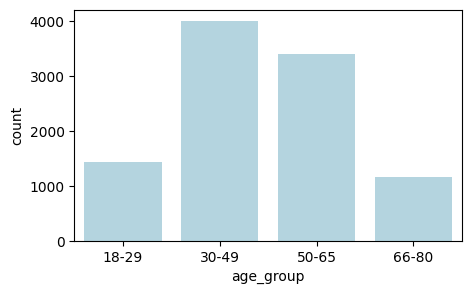

In [6]:
# Order the age_group column and change to categorical data type

# First, define the order of the age groups
age_group_order = ["18-29", "30-49", "50-65", "66-80"]

# Change the data type of the "age_group" column to categorical and parse with the specified order
df_cleaned["age_group"] = pd.Categorical(df_cleaned["age_group"], categories=age_group_order, ordered=True)

# Check the data type of the column "age_group" after conversion
print(f"Data type of 'age_group' column after conversion: {df_cleaned['age_group'].dtype}\n")

# Plot age ranges after ordering and changing the data type to confirm the change has been made
fig, axes = plt.subplots(figsize=(5, 3))
sns.countplot(data=df_cleaned, x="age_group", color="lightblue")
plt.show()

* Finally, I will change the data type for `donation_date`.
* *Note*: I don't foresee needing to use the entire donation date in any of these hypotheses below, but I will change the data type just in case.

In [7]:
# Change the data type of the "donation_date" column to datetime
df_cleaned["donation_date"] = pd.to_datetime(df_cleaned["donation_date"], format="%Y-%m-%d")

# Check the data type of the column "donation_date" after conversion
print(f"Data type of 'donation_date' column after conversion: {df_cleaned["donation_date"].dtype}\n")

# Print the first few rows of the dataset to verify the changes
print(f"Sample values from 'donation_date' column after conversion:\n{df_cleaned["donation_date"].head()}")

Data type of 'donation_date' column after conversion: datetime64[ns]

Sample values from 'donation_date' column after conversion:
0   2024-10-24
1   2024-06-21
2   2024-08-21
3   2023-10-09
4   2024-09-01
Name: donation_date, dtype: datetime64[ns]


---

# Hypothesis 1

* This section will look to compare **donation amount** with **donor age group**

|**H1**| Donors aged 50 - 65 give more per transaction than other age brackets |
|--------------|---------------|

* The first thing I am going to do is create a boxplot in Plotly that shows the distribution of donation amounts per age group.

In [9]:
# Create a boxplot in Plotly to visualise donation amounts given by age group

fig = px.box(df_cleaned, x="age_group", y="donation_amount",
             category_orders={"age_group": ["18-29", "30-49", "50-65", "66-80"]},
             title="Donation Amounts by Age Group",
             labels={"age_group": "Age Group", "donation_amount": "Donation Amount"})
fig.show()


* *Troubleshooting Issues*: Despite having ordered the age groups in the previous section, Plotly did not take this order into account automatically when plotting (which appeared to be a different behaviour to that of the Seaborn plots). As a result, I needed to add in an additional argument when creating the boxplot - `category_orders`. I used this to explicitly specify the order of my categorical age groups.

* I chose to try a Plotly graph here to allow precise inspection of individual donation values by hovering - this was especially useful when assessing the IQR box.

* Because I am able to drill down into the data, I can see that the median donation amounts for the separate age groups are as follows

|**age_group**| **Median donation amount**|
|------------|-----------------|
|18-29| €14.29 *(rounded to 2 decimals)*|
|30-49| €29.62|
|50-65| €34.97|
|66-80| €25.30 *(rounded to 2 decimals)*|

* I wanted to check the median amounts, because there are a lot of high-value outliers and I want to see what the median donation amounts are between the four age groups before going on to assess the mean.

* I am now going to work out the mean donation amount for each age group and present this in a bar graph.

In [10]:
# First, calculate the mean donation amount for each age group
age_mean_donations = df_cleaned.groupby("age_group", observed=False)["donation_amount"].mean()

# Show these mean doantion amounts
print(f"Mean donation amounts by age group:\n{age_mean_donations}")

Mean donation amounts by age group:
age_group
18-29    25.855845
30-49    51.950155
50-65    63.354449
66-80    48.532751
Name: donation_amount, dtype: float64


* *Troubleshooting Issues*: When I first completed this code, I received a FutureWarning error ("The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.") 
Having looked up the [pandas.DataFrame.groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) documentation, I found that the `observed` argument relates to categorical grouped data, where `True` shows only the groups where there are values, whereas `False` shows all. Given that I completed cleaning already in **Stage 2 - ETL**, I expected the results to be the same and practiced with both before making a decision.

* I was unsure how best to convert this Pandas Series into a Bar Plot, so I made the decision to try and convert the Series into a Dataframe so that I could use two column names `age_group` and `mean_donation_amount` as my `x` and `y` axes. I found a very useful **Stack Overflow** forum entry with a worked example using `.to_frame()`.
* Because I also needed to ensure that the mean donation amounts were rounded to 2 decimal places (as currency), I decided to use method chaining for the functions applied to `age_mean_donations` to make it clearer to read.

In [13]:
# Create a DataFrame for the mean donations by age group, using the above pandas Series

df_mean_donations = (age_mean_donations
                     .to_frame()
                     .reset_index()
                     .round(2))
df_mean_donations

,age_group,donation_amount
0,18-29,25.86
1,30-49,51.95
2,50-65,63.35
3,66-80,48.53


In [17]:
# Rename the "donation_amount" column to "mean_donation_amount"
df_mean_donations = df_mean_donations.rename(columns={"donation_amount": "mean_donation_amount"})
df_mean_donations

,age_group,mean_donation_amount
0,18-29,25.86
1,30-49,51.95
2,50-65,63.35
3,66-80,48.53


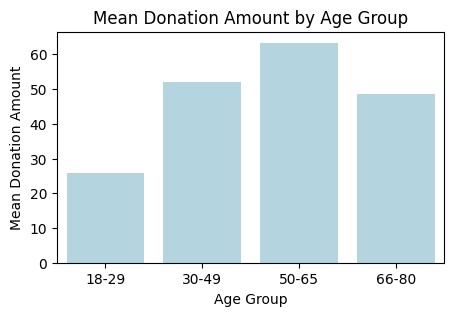

In [15]:
# Create a Bar Chart using Seaborn to show the mean donation amounts by age group

fig, axes = plt.subplots(figsize=(5, 3))

sns.barplot(data=df_mean_donations, x="age_group", y="mean_donation_amount", color="lightblue")

plt.title("Mean Donation Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean Donation Amount")
plt.show()

* This bar plot is a much better means of demonstrating the average donation amount given by an individual in each of the age categories.

**RESULT**
* Hypothesis 1 has been validated as being true. 
* As we can see from the bar plot and from our mean donations DataFrame, donors who fall in the age bracket 50-65 give more on average (€63.35).
* From the Plotly boxplot, we can also see that median donation amount for donors in the 50-65 age bracket was the highest (€34.97).

---

# Hypothesis 2

* This section will look at the **giving trend over time**.

|**H2**| The highest number of donations in the year will come in December |
|--------------|---------------|

* In order to investigate this hypothesis, I am going to use a Matplotlib line graph, as these are a good tool when analysing trends over a continuous period of time.

In [16]:
# First, calculate the number of donations per month

donation_count_month = (df_cleaned["donation_month"]
                        .value_counts()
                        .sort_index()) # I need to sort the index so that the months are in chronological order

print(donation_count_month)

donation_month
1     861
2     783
3     869
4     799
5     826
6     829
7     834
8     806
9     881
10    845
11    805
12    862
Name: count, dtype: int64


* Now that I have counted the donations per month, I can plot these using Matplotlib.

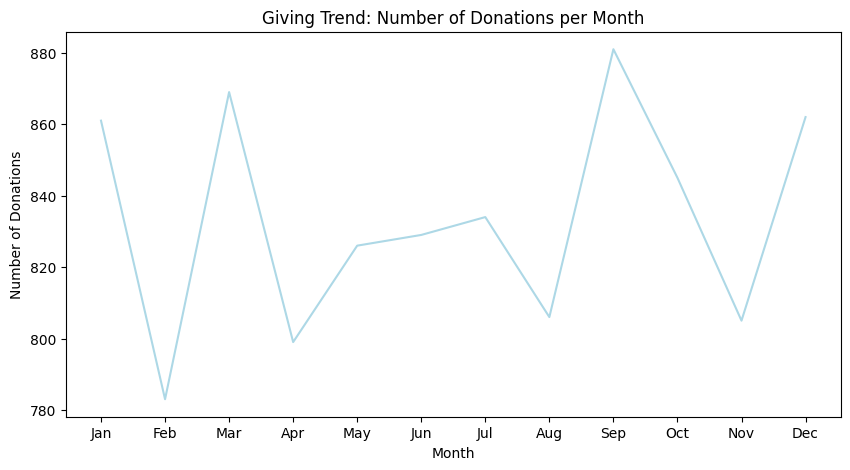

In [22]:
plt.figure(figsize=(10, 5))

# Create a line graph to show the number of donations per month
plt.plot(donation_count_month.index, donation_count_month.values, color="lightblue")
plt.title("Giving Trend: Number of Donations per Month")
plt.xlabel("Month")
plt.ylabel("Number of Donations")
plt.xticks([1,2,3,4,5,6,7,8,9,10,11, 12], ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.show()


* *Notes on Process*: In this graph, I used the [matplot.pyplot.xticks](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html) documentation examples to work out how to change the x-axis tick values to month name abbreviations.

**RESULT**
* Hypothesis 2 has not been validated. 
* Despite there being a definite uptick in the number of donations in December when compared to November, over the course of three years (2023, 2024 and 2025) the month with the highest number of donations is September. 

---

# Hypothesis 3

---